# CASE 1·2 분류모형 그래프 재생성

## 목적과 범위

`260726_CASE1_CASE2_분류모형.ipynb`의 저장 결과를 이용해 원본 그래프
10개를 Pretendard 글꼴로 다시 그리고, 원본에 없던 Base 도메인 중요도
그래프를 Full과 같은 방식으로 추가해 총 11개를 그린다.

- 원 실행 결과:
  `outputs/260726_CASE1_CASE2_분류모형_260725_2038/`
- 분석 단위: 응답자·조사회차 1행
- 키: `YEAR + ID`
- 모든 N과 성능 지표: 비가중
- 모델 파이프라인을 읽지 않으며 `.fit()`과 `.predict()`를 호출하지 않는다.
- CSV·NPZ 결과와 표본 구성 확인용 전처리 CSV만 읽는다.
- SHAP 변수명은 공식 표시명과 파생 규칙을 이용해 한국어로 바꾼다.
- 원본 노트북과 원 실행 결과는 수정하지 않는다.

CASE 2는 관광·휴양 활동을 포함한 가족·친지·친구 방문이며, 출생지나
법적 고향을 직접 측정한 개념이 아니다.

## 1. 환경, 공통 경로와 재현성 설정

프로젝트 루트를 찾고 `src.path`와 `src.visualization`의 공통 경로·색상·
Pretendard 글꼴 설정을 사용한다. 새 그림은 이 노트북 전용 출력 폴더에
900 DPI PNG로 저장한다.

In [1]:
from pathlib import Path
import json
import sys
from textwrap import fill


PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").is_dir():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError(
            "src 폴더가 있는 프로젝트 루트를 찾지 못했습니다."
        )
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_FILENAME = (
    "260726_CASE1_CASE2_분류모형_그래프재생성.ipynb"
)
SOURCE_RUN_NAME = "260726_CASE1_CASE2_분류모형_260725_2038"

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from IPython.display import display
from sklearn.metrics import precision_recall_curve

from src.path import (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR,
    OUTPUTS_DIR,
    create_output_directories,
)
from src.visualization import COLORS, apply_plot_style


apply_plot_style()

FIGURES_DIR, TABLES_DIR = create_output_directories(
    NOTEBOOK_FILENAME
)
SOURCE_RUN_DIR = OUTPUTS_DIR / SOURCE_RUN_NAME
SOURCE_TABLES_DIR = SOURCE_RUN_DIR / "tables"
SOURCE_MODELS_DIR = SOURCE_RUN_DIR / "models"
SURVEY_PATH = (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR
    / "national_travel_survey_2023_2025_preprocessed.csv"
)
DISPLAY_NAME_PATH = (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR
    / "national_travel_survey_2023_2025_display_name.csv"
)
CODEBOOK_PATH = (
    NATIONAL_TRAVEL_SURVEY_PREPROCESSED_DATA_DIR
    / "national_travel_survey_2023_2025_preprocessed_codebook.csv"
)
FEATURE_LABEL_WRAP_WIDTH = 22
SHAP_CMAP = LinearSegmentedColormap.from_list(
    "project_shap",
    [
        COLORS["primary"],
        COLORS["neutral"],
        COLORS["accent"],
    ],
)

print(f"원 실행 결과: {SOURCE_RUN_DIR}")
print(f"새 그림 저장 경로: {FIGURES_DIR}")

원 실행 결과: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_260725_2038
새 그림 저장 경로: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures


c:\Users\ilove\OneDrive\Desktop\tourism_poster\tourism\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 저장 결과와 표본 구성 데이터 로드

모델을 다시 적합하지 않고 저장된 평가표·예측 확률·SHAP 배열을 읽는다.
첫 번째 그래프의 표본 흐름만 원본과 같은 정의로 재집계하기 위해 통합
전처리 CSV에서 `YEAR`, `D_TRA_CASE` 두 열만 읽는다.

In [3]:
required_paths = [
    SURVEY_PATH,
    DISPLAY_NAME_PATH,
    CODEBOOK_PATH,
    SOURCE_TABLES_DIR / "validation_leaderboard.csv",
    SOURCE_TABLES_DIR / "paired_bootstrap_distribution.csv",
    SOURCE_TABLES_DIR / "paired_bootstrap_summary.csv",
    SOURCE_TABLES_DIR / "final_test_metrics.csv",
    SOURCE_TABLES_DIR / "final_test_confusion_matrix.csv",
    SOURCE_TABLES_DIR / "sensitivity_comparison.csv",
    SOURCE_MODELS_DIR / "final_test_predictions.csv",
    SOURCE_MODELS_DIR / "run_metadata.json",
]
missing_paths = [
    path for path in required_paths if not path.is_file()
]
if missing_paths:
    missing_text = "\n".join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        f"재시각화에 필요한 파일이 없습니다.\n{missing_text}"
    )

with (SOURCE_MODELS_DIR / "run_metadata.json").open(
    encoding="utf-8"
) as file:
    run_metadata = json.load(file)

assert run_metadata["status"] == "completed"
print(
    "원 실행 완료 상태 확인:",
    run_metadata["completed_at"],
)

원 실행 완료 상태 확인: 2026-07-26T03:45:01


In [4]:
survey_data = pd.read_csv(
    SURVEY_PATH,
    usecols=["YEAR", "D_TRA_CASE"],
    low_memory=False,
)
survey_data["D_TRA_CASE"] = pd.to_numeric(
    survey_data["D_TRA_CASE"],
    errors="coerce",
)
analysis_data = survey_data.loc[
    survey_data["D_TRA_CASE"].isin([1, 2])
].copy()
analysis_data["target"] = (
    analysis_data["D_TRA_CASE"].eq(2).astype("int8")
)

sample_flow = pd.DataFrame(
    {
        "단계": [
            "전체 응답자·조사회차",
            "CASE 1·2 분석 표본",
            "CASE 1",
            "CASE 2",
        ],
        "비가중_N": [
            len(survey_data),
            len(analysis_data),
            analysis_data["target"].eq(0).sum(),
            analysis_data["target"].eq(1).sum(),
        ],
    }
)
year_case = (
    analysis_data.groupby(
        ["YEAR", "target"],
        observed=True,
    )
    .size()
    .rename("비가중_N")
    .reset_index()
)
year_case["CASE"] = year_case["target"].map(
    {0: "CASE 1", 1: "CASE 2"}
)
year_case["연도내_비율"] = (
    year_case["비가중_N"]
    / year_case.groupby("YEAR")["비가중_N"].transform("sum")
)

display(sample_flow)
display(
    year_case[
        ["YEAR", "CASE", "비가중_N", "연도내_비율"]
    ]
)

,단계,비가중_N
0,전체 응답자·조사회차,156050
1,CASE 1·2 분석 표본,70694
2,CASE 1,57904
3,CASE 2,12790


,YEAR,CASE,비가중_N,연도내_비율
0,2023,CASE 1,19446,0.814390
1,2023,CASE 2,4432,0.185610
2,2024,CASE 1,18917,0.806489
3,2024,CASE 2,4539,0.193511
4,2025,CASE 1,19541,0.836515
5,2025,CASE 2,3819,0.163485


In [5]:
validation_leaderboard = pd.read_csv(
    SOURCE_TABLES_DIR / "validation_leaderboard.csv"
)
bootstrap_results = pd.read_csv(
    SOURCE_TABLES_DIR / "paired_bootstrap_distribution.csv"
)
bootstrap_summary = pd.read_csv(
    SOURCE_TABLES_DIR / "paired_bootstrap_summary.csv"
)
final_test_metrics = pd.read_csv(
    SOURCE_TABLES_DIR / "final_test_metrics.csv"
)
final_confusion_table = pd.read_csv(
    SOURCE_TABLES_DIR / "final_test_confusion_matrix.csv"
)
sensitivity_comparison = pd.read_csv(
    SOURCE_TABLES_DIR / "sensitivity_comparison.csv"
)
final_test_predictions = pd.read_csv(
    SOURCE_MODELS_DIR / "final_test_predictions.csv"
)

best_base_row = validation_leaderboard.loc[
    validation_leaderboard["tier"].eq("Base")
].iloc[0]
best_full_row = validation_leaderboard.loc[
    validation_leaderboard["tier"].eq("Full")
].iloc[0]
best_base_predictions = pd.read_csv(
    SOURCE_MODELS_DIR
    / (
        "base_"
        f"{best_base_row['model']}"
        "_validation_predictions.csv"
    ),
    usecols=["YEAR", "ID", "target"],
)
validation_n = len(best_base_predictions)
bootstrap_iterations = int(
    bootstrap_summary["iterations"].iloc[0]
)
test_metrics = final_test_metrics.iloc[0].to_dict()
test_confusion_matrix = (
    final_confusion_table[
        ["예측 CASE 1", "예측 CASE 2"]
    ].to_numpy(dtype=int)
)

display(validation_leaderboard)
display(final_test_metrics)

,tier,model,threshold,f1,precision,recall,pr_auc,roc_auc
0,Full,lightgbm,0.615,0.687812,0.788022,0.610214,0.729890,0.873743
1,Full,xgboost,0.350,0.684148,0.798887,0.598228,0.729496,0.871261
2,Full,catboost,0.580,0.680382,0.766319,0.611777,0.729926,0.872404
3,Full,random_forest,0.505,0.651136,0.737954,0.582595,0.698927,0.858178
4,Base,xgboost,0.280,0.648679,0.712859,0.595102,0.699125,0.852390
5,Base,lightgbm,0.640,0.647921,0.760534,0.564356,0.697295,0.852821
6,Base,catboost,0.610,0.643314,0.774194,0.550287,0.686860,0.846160
7,Base,random_forest,0.445,0.633846,0.684179,0.590412,0.686615,0.848211
8,Base,elastic_net,0.285,0.626596,0.778638,0.524231,0.666604,0.835084
9,Full,elastic_net,0.180,0.330986,0.199131,0.979677,0.660382,0.832981


,tier,model,threshold,f1,precision,recall,pr_auc,roc_auc,test_N
0,Full,lightgbm,0.615,0.672388,0.778082,0.591975,0.72637,0.867407,10605


In [6]:
def load_shap_result(
    tier: str,
    model_name: str,
) -> dict[str, object]:
    """저장된 SHAP 배열과 집계표를 읽는다.

    Args:
        tier: `Base` 또는 `Full` 피처 계층이다.
        model_name: 저장 파일명에 사용된 모델 이름이다.

    Returns:
        SHAP 배열, 입력값, 변환 피처명과 집계표를 담은 사전이다.
    """
    prefix = f"{tier.lower()}_{model_name}"
    npz_path = (
        SOURCE_MODELS_DIR / f"{prefix}_shap_values.npz"
    )
    original_path = (
        SOURCE_TABLES_DIR
        / f"{prefix}_shap_original_features.csv"
    )
    domain_path = (
        SOURCE_TABLES_DIR / f"{prefix}_shap_domains.csv"
    )
    transformed_path = (
        SOURCE_TABLES_DIR
        / f"{prefix}_shap_transformed_features.csv"
    )
    for path in (
        npz_path,
        original_path,
        domain_path,
        transformed_path,
    ):
        if not path.is_file():
            raise FileNotFoundError(
                f"SHAP 재시각화 파일이 없습니다: {path}"
            )

    with np.load(npz_path, allow_pickle=False) as bundle:
        values = bundle["shap_values"].copy()
        data = bundle["explained_values"].copy()
        feature_names = bundle[
            "transformed_feature_names"
        ].astype(str)
        sample_positions = bundle[
            "sample_positions"
        ].copy()

    return {
        "values": values,
        "data": data,
        "feature_names": feature_names,
        "sample_positions": sample_positions,
        "original_summary": pd.read_csv(original_path),
        "domain_summary": pd.read_csv(domain_path),
        "transformed_summary": pd.read_csv(
            transformed_path
        ),
    }


shap_results = {
    "Base": load_shap_result(
        "Base",
        str(best_base_row["model"]),
    ),
    "Full": load_shap_result(
        "Full",
        str(best_full_row["model"]),
    ),
}
shap_sample_n = len(
    shap_results["Base"]["sample_positions"]
)

## 3. SHAP 변수 표시명 전처리

원변수는 `national_travel_survey_2023_2025_display_name.csv`의 짧은
한국어 표시명을 사용한다. 파생변수는 원천 변수 표시명에 지출액·비중·
여부·구간 등의 파생 의미를 붙인다. 범주형 SHAP 항목은 통합 코드북의
값 라벨까지 결합하고, 긴 이름은 단어 경계를 유지해 줄바꿈한다.

In [7]:
display_names = pd.read_csv(
    DISPLAY_NAME_PATH,
    encoding="utf-8-sig",
)
codebook = pd.read_csv(
    CODEBOOK_PATH,
    encoding="utf-8-sig",
)
assert {
    "column_name",
    "display_name",
}.issubset(display_names.columns)
assert display_names["column_name"].is_unique

display_name_map = display_names.set_index("column_name")[
    "display_name"
].to_dict()


def parse_value_labels(value: object) -> dict[str, str]:
    """코드북의 JSON 값 라벨을 문자열 사전으로 바꾼다.

    Args:
        value: `integrated_value_labels` 열의 값이다.

    Returns:
        코드와 한국어 값 라벨의 사전이다.
    """
    if pd.isna(value) or not str(value).strip():
        return {}
    parsed = json.loads(value)
    return {
        str(key): str(label).strip()
        for key, label in parsed.items()
    }


value_label_map = {
    row.column_name: parse_value_labels(
        row.integrated_value_labels
    )
    for row in codebook.itertuples(index=False)
}

DERIVED_DISPLAY_NAMES = {
    "age_group": "연령대",
    "household_income_band": "가구소득 구간",
    "household_size": "동거가구원 수",
    "marital_status": "혼인상태",
    "household_with_child": "자녀·손자녀 동거 여부",
    "season": "여행 계절",
    "overnight_type": "당일·숙박여행 유형",
    "trip_days_band": "여행일수 구간",
    "includes_weekday": "평일 포함 여부",
    "includes_weekend": "주말 포함 여부",
    "includes_holiday": "공휴일 포함 여부",
    "party_size_band": "동행 인원 구간",
    "with_child": "미성년자 동반 여부",
    "companion_type_count": "동반자 유형 수",
    "with_family_relative": "가족·친척 동반 여부",
    "with_friend": "친구·연인 동반 여부",
    "uses_car_or_rental": "자가용·렌터카 이용 여부",
    "uses_public_transport": "대중교통 이용 여부",
    "uses_other_transport": "기타 교통수단 이용 여부",
    "transport_mode_count": "이용 교통수단 수",
    "visit_scope": "거주지 기준 방문 범위",
    "capital_visit_pattern": "수도권 방문 유형",
    "visit_region_scope": "단일·다지역 방문 유형",
    "lodging_summary": "숙박시설 유형",
    "family_home_only": "가족·친지집만 이용",
    "has_reservation": "사전예약 여부",
    "reservation_count": "사전예약 항목 수",
    "reserved_transport": "교통 사전예약 여부",
    "reserved_lodging": "숙박 사전예약 여부",
    "reserved_activity": "활동 사전예약 여부",
    "information_none": "여행정보 미이용",
    "information_online": "온라인 여행정보 이용",
    "information_people": "주변인 여행정보 이용",
    "information_source_count": "여행정보 획득 경로 수",
    "activity_nature": "자연·경관 활동 여부",
    "activity_food": "음식관광 활동 여부",
    "activity_culture": "문화·예술 활동 여부",
    "activity_experience": "체험 활동 여부",
    "activity_leisure": "레저·오락 활동 여부",
    "activity_wellness": "휴식·휴양 활동 여부",
    "activity_shopping": "쇼핑 활동 여부",
    "activity_event": "축제·이벤트 활동 여부",
    "activity_group_count": "참여 활동 대분류 수",
    "spend_per_person_day": "1인·1일 여행경비",
    "log_spend_per_person_day": (
        "1인·1일 여행경비 로그값"
    ),
}
CATEGORY_SOURCE_VARIABLES = {
    "age_group": "BAGE",
    "household_income_band": "BINC1",
    "household_size": "BFAM",
    "marital_status": "BMAR",
}
SIDO_NAMES = {
    11: "서울",
    21: "부산",
    22: "대구",
    23: "인천",
    24: "광주",
    25: "대전",
    26: "울산",
    29: "세종",
    31: "경기",
    32: "강원",
    33: "충북",
    34: "충남",
    35: "전북",
    36: "전남",
    37: "경북",
    38: "경남",
    39: "제주",
}
LODGING_LABELS = value_label_map["D_TRA_1_Q6"]


def source_variable_name(feature: str) -> str | None:
    """지출 파생변수의 원변수명을 찾는다.

    Args:
        feature: 분류모형 피처 이름이다.

    Returns:
        대응하는 원변수명 또는 대응이 없으면 `None`이다.
    """
    prefixes = ("amount_", "share_", "spent_")
    if not feature.startswith(prefixes):
        return None
    return feature.split("_", 1)[1].upper()


def feature_display_name(feature: str) -> str:
    """원변수와 파생변수를 한국어 표시명으로 바꾼다.

    Args:
        feature: 분류모형의 원 피처 이름이다.

    Returns:
        그래프에 표시할 한국어 의미명이다.
    """
    if feature in DERIVED_DISPLAY_NAMES:
        return DERIVED_DISPLAY_NAMES[feature]
    if feature in display_name_map:
        return str(display_name_map[feature])

    source = source_variable_name(feature)
    if source is not None:
        source_label = str(
            display_name_map.get(source, source)
        )
        if feature.startswith("amount_"):
            if source_label.endswith("지출"):
                return f"{source_label}액"
            if source_label.endswith(("지출액", "비용")):
                return source_label
            return f"{source_label} 지출액"
        if feature.startswith("share_"):
            return f"{source_label} 비중"
        return f"{source_label} 지출 여부"

    if feature.startswith("has_lodging_"):
        code = feature.removeprefix("has_lodging_")
        label = LODGING_LABELS.get(code, f"숙박시설 {code}")
        label = label.replace("/", "·")
        return f"{label} 이용 여부"
    if feature.startswith("visit_sido_"):
        code = int(feature.removeprefix("visit_sido_"))
        label = SIDO_NAMES.get(code, f"시도 {code}")
        return f"{label} 방문 여부"

    return feature.replace("_", " ")


def canonical_level_code(value: str) -> str:
    """원-핫 범주 코드를 코드북 조회용 문자열로 정규화한다.

    Args:
        value: 변환 피처명에서 분리한 범주값이다.

    Returns:
        정수형 실수 표기를 정리한 문자열 코드다.
    """
    try:
        numeric = float(value)
    except ValueError:
        return value
    if numeric.is_integer():
        return str(int(numeric))
    return value


def feature_level_label(
    feature: str,
    level: str,
) -> str:
    """범주형 피처의 코드값을 의미 라벨로 바꾼다.

    Args:
        feature: 원 피처 이름이다.
        level: 변환 피처명에서 분리한 범주값이다.

    Returns:
        코드북 또는 파생 범주의 표시 라벨이다.
    """
    source = CATEGORY_SOURCE_VARIABLES.get(feature, feature)
    code = canonical_level_code(level)
    label = value_label_map.get(source, {}).get(code, level)
    boolean_labels = {
        "True": "예",
        "False": "아니요",
        "true": "예",
        "false": "아니요",
    }
    return boolean_labels.get(str(label), str(label))


def transformed_feature_display_name(
    transformed_feature: str,
    original_feature: str,
) -> str:
    """변환 피처명을 원 피처 의미와 범주 라벨로 풀어 쓴다.

    Args:
        transformed_feature: 전처리 후 피처 이름이다.
        original_feature: 대응하는 전처리 전 피처 이름이다.

    Returns:
        SHAP beeswarm에 표시할 의미명이다.
    """
    base_label = feature_display_name(original_feature)
    stripped = transformed_feature.split("__", 1)[-1]
    prefix = f"{original_feature}_"
    if stripped == original_feature:
        return base_label
    if stripped.startswith(prefix):
        level = stripped[len(prefix):]
        level_label = feature_level_label(
            original_feature,
            level,
        )
        return f"{base_label} — {level_label}"
    return base_label


def wrap_feature_label(label: str) -> str:
    """긴 피처 표시명을 단어 경계에서 줄바꿈한다.

    Args:
        label: 줄바꿈 전 한국어 의미명이다.

    Returns:
        지정 폭으로 줄바꿈한 표시명이다.
    """
    return fill(
        str(label),
        width=FEATURE_LABEL_WRAP_WIDTH,
        break_long_words=False,
        break_on_hyphens=False,
    )


def contains_hangul(label: str) -> bool:
    """표시명에 한글 음절이 포함됐는지 확인한다.

    Args:
        label: 확인할 표시명이다.

    Returns:
        한글 음절이 하나 이상 있으면 `True`이다.
    """
    return any("가" <= char <= "힣" for char in str(label))


label_audit_rows = []
for tier, result in shap_results.items():
    transformed_lookup = (
        result["transformed_summary"]
        .set_index("transformed_feature")["original_feature"]
    )
    original_features = transformed_lookup.reindex(
        result["feature_names"]
    )
    assert original_features.notna().all()

    result["display_feature_names"] = [
        wrap_feature_label(
            transformed_feature_display_name(
                transformed_feature,
                original_feature,
            )
        )
        for transformed_feature, original_feature in zip(
            result["feature_names"],
            original_features,
        )
    ]

    for feature in result["original_summary"].head(
        20
    )["original_feature"]:
        display_label = feature_display_name(feature)
        label_audit_rows.append(
            {
                "tier": tier,
                "원 피처명": feature,
                "그래프 표시명": display_label,
            }
        )

label_audit = pd.DataFrame(label_audit_rows)
display(label_audit)

,tier,원 피처명,그래프 표시명
0,Base,family_home_only,가족·친지집만 이용
1,Base,lodging_summary,숙박시설 유형
2,Base,age_group,연령대
3,Base,share_a8b,여행·모임 회비 비중
4,Base,household_income_band,가구소득 구간
5,Base,trip_days_band,여행일수 구간
6,Base,includes_holiday,공휴일 포함 여부
7,Base,with_friend,친구·연인 동반 여부
8,Base,share_a8h,쇼핑비 비중
9,Base,season,여행 계절


## 4. 데이터 품질과 분석 단위 확인

원본 노트북의 표본 수, 모델 수, 예측 확률 범위, 혼동행렬 합계와 SHAP
배열 차원을 대조한다. 이 검증은 저장 결과를 읽기만 하며 모델 계산을
수행하지 않는다.

In [8]:
assert len(survey_data) == 156_050
assert len(analysis_data) == 70_694
assert analysis_data["target"].value_counts().to_dict() == {
    0: 57_904,
    1: 12_790,
}
assert len(validation_leaderboard) == 10
assert set(validation_leaderboard["tier"]) == {"Base", "Full"}
assert len(bootstrap_results) == bootstrap_iterations
assert validation_n == 10_604
assert len(final_test_predictions) == int(
    test_metrics["test_N"]
)
assert final_test_predictions["probability"].between(
    0,
    1,
    inclusive="both",
).all()
assert test_confusion_matrix.sum() == len(
    final_test_predictions
)
assert shap_sample_n == len(
    shap_results["Full"]["sample_positions"]
)

for tier, result in shap_results.items():
    values = result["values"]
    data = result["data"]
    feature_names = result["feature_names"]
    assert values.shape == data.shape
    assert values.shape[1] == len(feature_names)
    assert np.isfinite(values).all()
    top_original_labels = [
        feature_display_name(feature)
        for feature in result["original_summary"].head(
            20
        )["original_feature"]
    ]
    top_transformed_positions = np.argsort(
        np.abs(values).mean(axis=0)
    )[-20:]
    top_transformed_labels = [
        result["display_feature_names"][position]
        for position in top_transformed_positions
    ]
    assert all(
        contains_hangul(label)
        for label in (
            top_original_labels + top_transformed_labels
        )
    )
    print(
        f"{tier}: SHAP {values.shape[0]:,}행 × "
        f"{values.shape[1]:,}열"
    )

print("재시각화 입력 품질 검증을 통과했습니다.")

Base: SHAP 1,999행 × 101열
Full: SHAP 1,999행 × 488열
재시각화 입력 품질 검증을 통과했습니다.


## 5. 시각화

원본 그래프의 비교 대상, 축, 제목과 파일명을 유지한다. 색상은 프로젝트
`COLORS`만 사용하며 저장 전 Pretendard가 적용된 현재 Figure를 노트북에도
표시한다. SHAP 피처명은 한국어 의미명으로 바꾸고 긴 라벨은 줄바꿈한다.

In [9]:
generated_figure_paths = []


def save_figure(
    figure: plt.Figure,
    filename: str,
) -> Path:
    """그림을 900 DPI PNG로 저장하고 노트북에 표시한다.

    Args:
        figure: 저장할 Matplotlib Figure다.
        filename: 영문 snake_case PNG 파일명이다.

    Returns:
        저장된 그림의 절대 경로다.
    """
    output_path = FIGURES_DIR / filename
    figure.savefig(
        output_path,
        dpi=900,
        bbox_inches="tight",
    )
    display(figure)
    plt.close(figure)
    generated_figure_paths.append(output_path)
    print(f"저장: {output_path}")
    return output_path

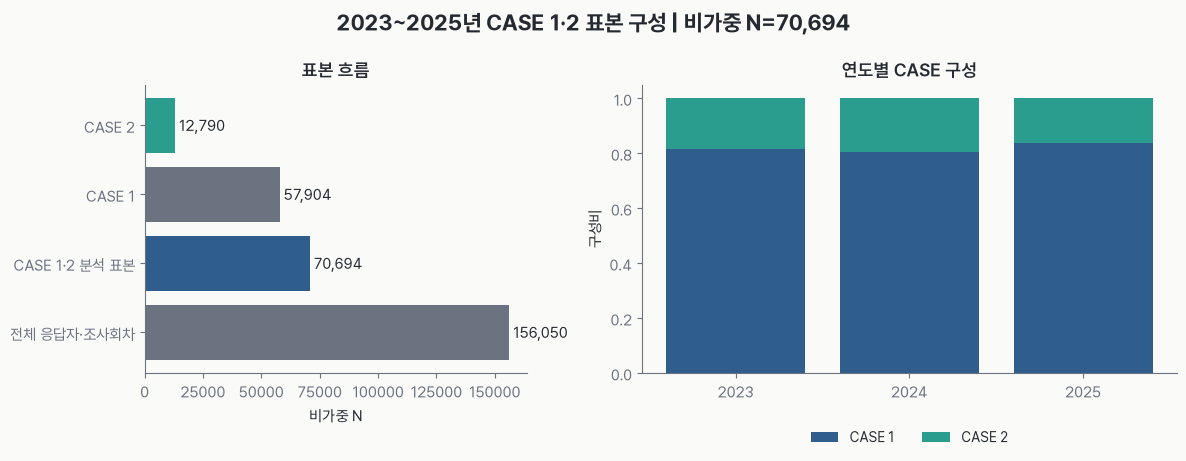

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\sample_flow_and_year_case_composition.png


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/outputs/260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200/figures/sample_flow_and_year_case_composition.png')

In [10]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8),
    gridspec_kw={"width_ratios": [1, 1.4]},
)
axes[0].barh(
    sample_flow["단계"],
    sample_flow["비가중_N"],
    color=[
        COLORS["neutral"],
        COLORS["primary"],
        COLORS["neutral"],
        COLORS["secondary"],
    ],
)
for index, value in enumerate(sample_flow["비가중_N"]):
    axes[0].text(value, index, f" {value:,}", va="center")
axes[0].set_title("표본 흐름")
axes[0].set_xlabel("비가중 N")

year_pivot = year_case.pivot(
    index="YEAR",
    columns="CASE",
    values="연도내_비율",
).fillna(0)
axes[1].bar(
    year_pivot.index.astype(str),
    year_pivot["CASE 1"],
    label="CASE 1",
    color=COLORS["primary"],
)
axes[1].bar(
    year_pivot.index.astype(str),
    year_pivot["CASE 2"],
    bottom=year_pivot["CASE 1"],
    label="CASE 2",
    color=COLORS["secondary"],
)
axes[1].set_title("연도별 CASE 구성")
axes[1].set_ylabel("구성비")
axes[1].legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
)
figure.suptitle(
    "2023~2025년 CASE 1·2 표본 구성 | "
    f"비가중 N={len(analysis_data):,}"
)
figure.tight_layout()
save_figure(
    figure,
    "sample_flow_and_year_case_composition.png",
)

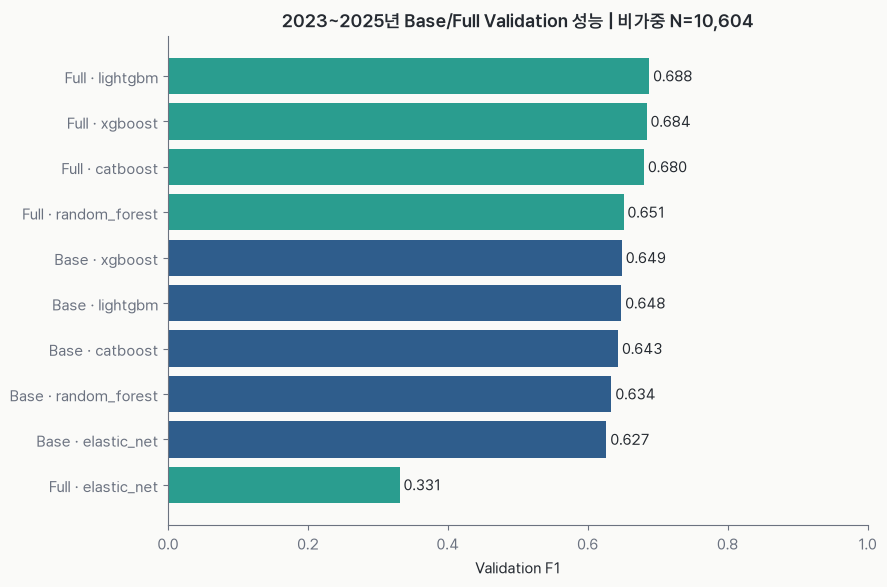

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\validation_leaderboard_f1.png


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/outputs/260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200/figures/validation_leaderboard_f1.png')

In [11]:
leaderboard_plot = validation_leaderboard.copy()
leaderboard_plot["label"] = (
    leaderboard_plot["tier"]
    + " · "
    + leaderboard_plot["model"]
)
leaderboard_plot = leaderboard_plot.sort_values("f1")
colors = leaderboard_plot["tier"].map(
    {
        "Base": COLORS["primary"],
        "Full": COLORS["secondary"],
    }
)
figure, axis = plt.subplots(figsize=(9, 6))
axis.barh(
    leaderboard_plot["label"],
    leaderboard_plot["f1"],
    color=colors,
)
for index, value in enumerate(leaderboard_plot["f1"]):
    axis.text(value, index, f" {value:.3f}", va="center")
axis.set_xlim(
    0,
    max(1.0, leaderboard_plot["f1"].max() + 0.08),
)
axis.set_xlabel("Validation F1")
axis.set_title(
    "2023~2025년 Base/Full Validation 성능 | "
    f"비가중 N={validation_n:,}"
)
figure.tight_layout()
save_figure(figure, "validation_leaderboard_f1.png")

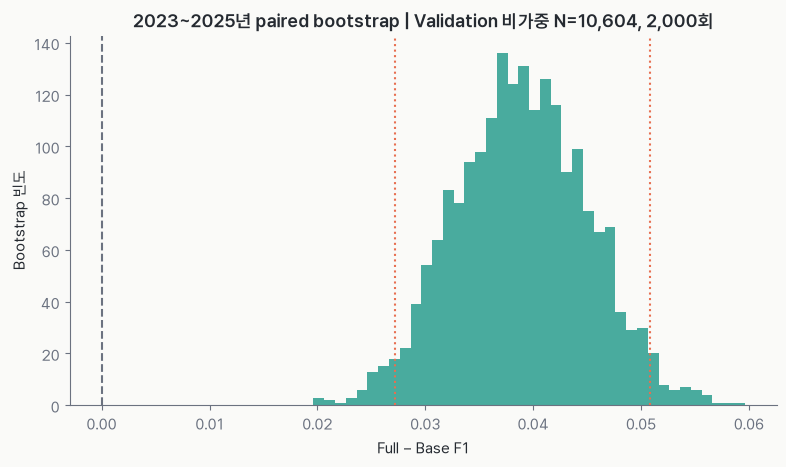

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\paired_bootstrap_f1_difference.png


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/outputs/260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200/figures/paired_bootstrap_f1_difference.png')

In [12]:
figure, axis = plt.subplots(figsize=(8, 4.8))
axis.hist(
    bootstrap_results["full_minus_base_f1"],
    bins=40,
    color=COLORS["secondary"],
    alpha=0.85,
)
axis.axvline(
    0,
    color=COLORS["neutral"],
    linestyle="--",
)
axis.axvline(
    bootstrap_summary["ci_2_5"].iloc[0],
    color=COLORS["accent"],
    linestyle=":",
)
axis.axvline(
    bootstrap_summary["ci_97_5"].iloc[0],
    color=COLORS["accent"],
    linestyle=":",
)
axis.set_xlabel("Full − Base F1")
axis.set_ylabel("Bootstrap 빈도")
axis.set_title(
    "2023~2025년 paired bootstrap | "
    f"Validation 비가중 N={validation_n:,}, "
    f"{bootstrap_iterations:,}회"
)
figure.tight_layout()
save_figure(figure, "paired_bootstrap_f1_difference.png")

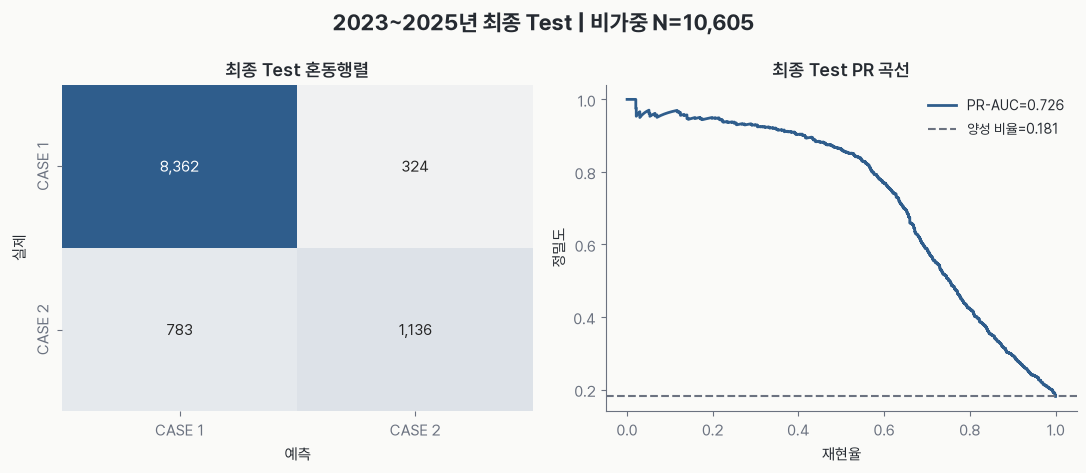

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\final_test_confusion_matrix_and_pr_curve.png


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/outputs/260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200/figures/final_test_confusion_matrix_and_pr_curve.png')

In [13]:
y_test = final_test_predictions["target"].astype(int)
test_probabilities = final_test_predictions[
    "probability"
].to_numpy()

figure, axes = plt.subplots(1, 2, figsize=(11, 4.8))
sns.heatmap(
    test_confusion_matrix,
    annot=True,
    fmt=",d",
    cmap=sns.light_palette(
        COLORS["primary"],
        as_cmap=True,
    ),
    cbar=False,
    xticklabels=["CASE 1", "CASE 2"],
    yticklabels=["CASE 1", "CASE 2"],
    ax=axes[0],
)
axes[0].set_xlabel("예측")
axes[0].set_ylabel("실제")
axes[0].set_title("최종 Test 혼동행렬")

precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    test_probabilities,
)
axes[1].plot(
    recall_values,
    precision_values,
    color=COLORS["primary"],
    linewidth=2,
    label=f"PR-AUC={test_metrics['pr_auc']:.3f}",
)
axes[1].axhline(
    y_test.mean(),
    color=COLORS["neutral"],
    linestyle="--",
    label=f"양성 비율={y_test.mean():.3f}",
)
axes[1].set_xlabel("재현율")
axes[1].set_ylabel("정밀도")
axes[1].set_title("최종 Test PR 곡선")
axes[1].legend(frameon=False)
figure.suptitle(
    f"2023~2025년 최종 Test | 비가중 N={len(y_test):,}"
)
figure.tight_layout()
save_figure(
    figure,
    "final_test_confusion_matrix_and_pr_curve.png",
)

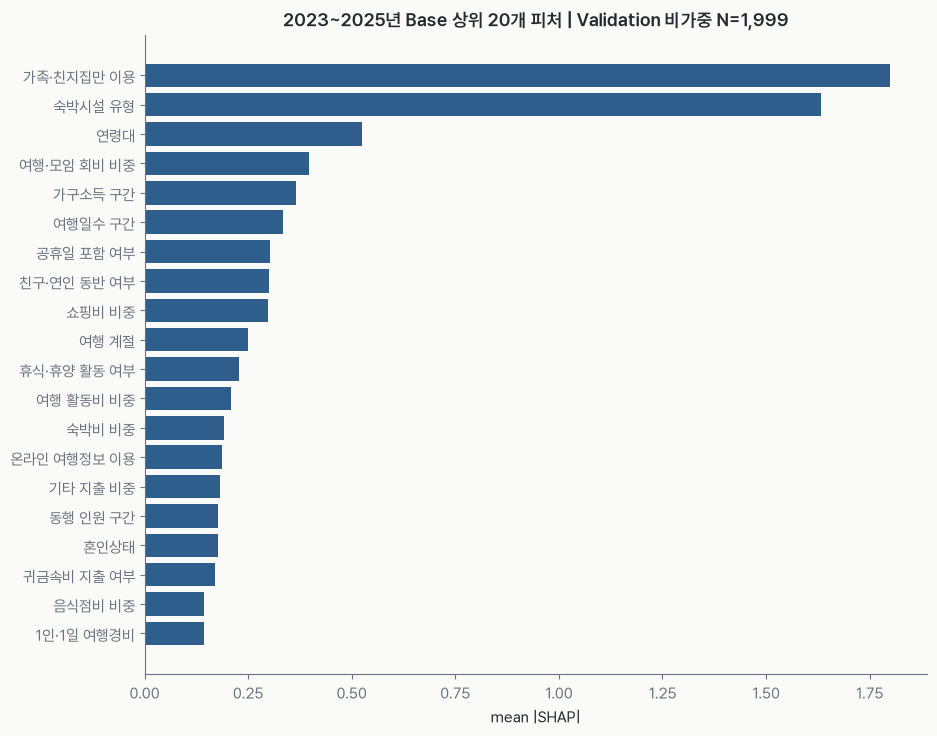

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\base_shap_original_feature_bar.png


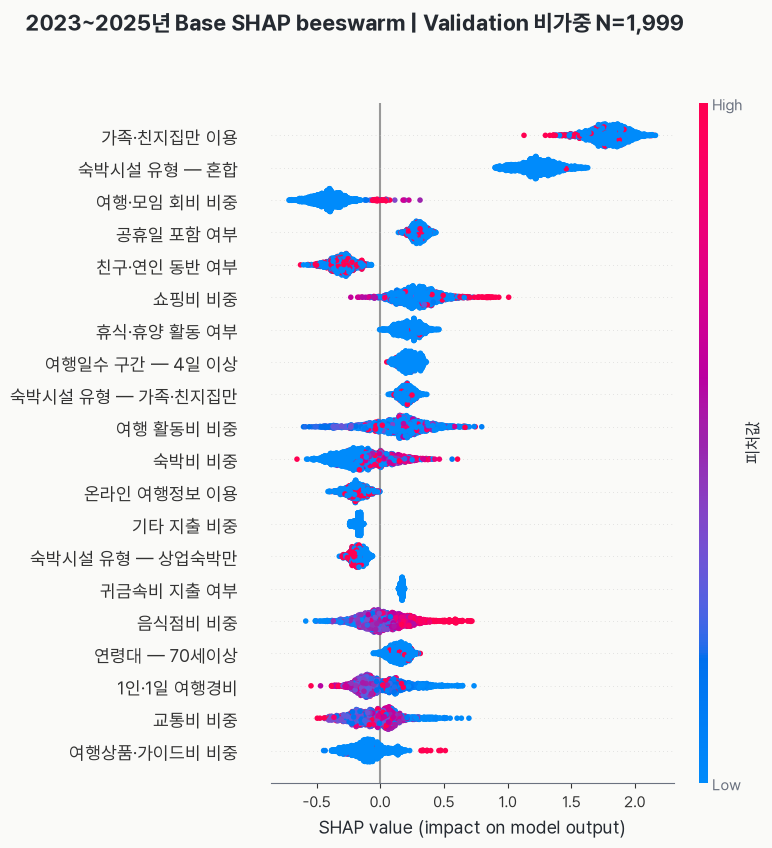

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\base_shap_beeswarm.png


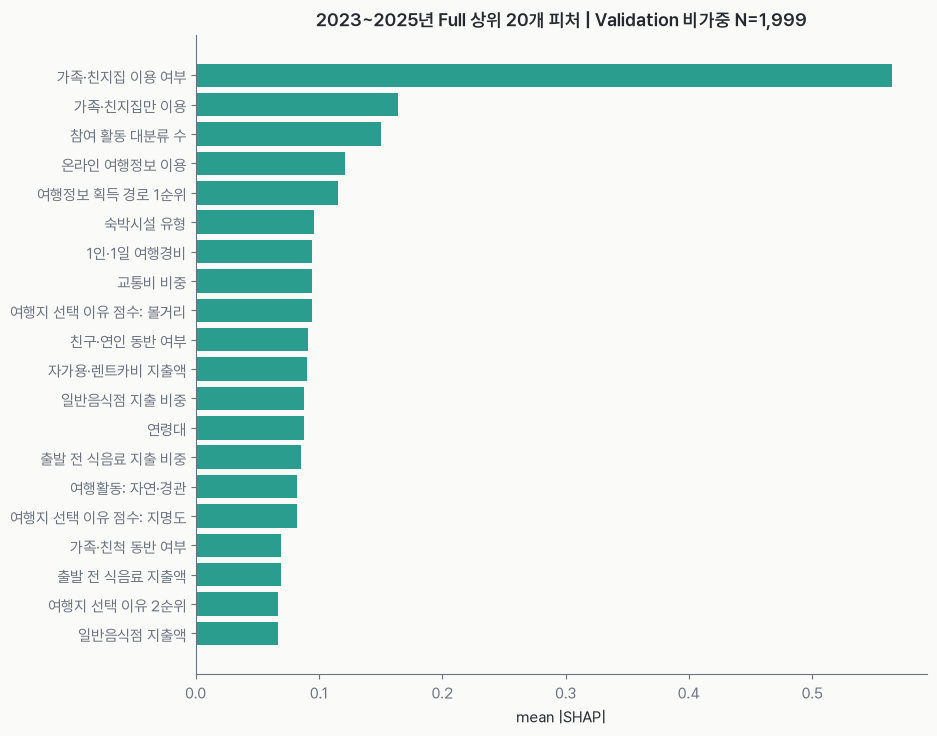

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\full_shap_original_feature_bar.png


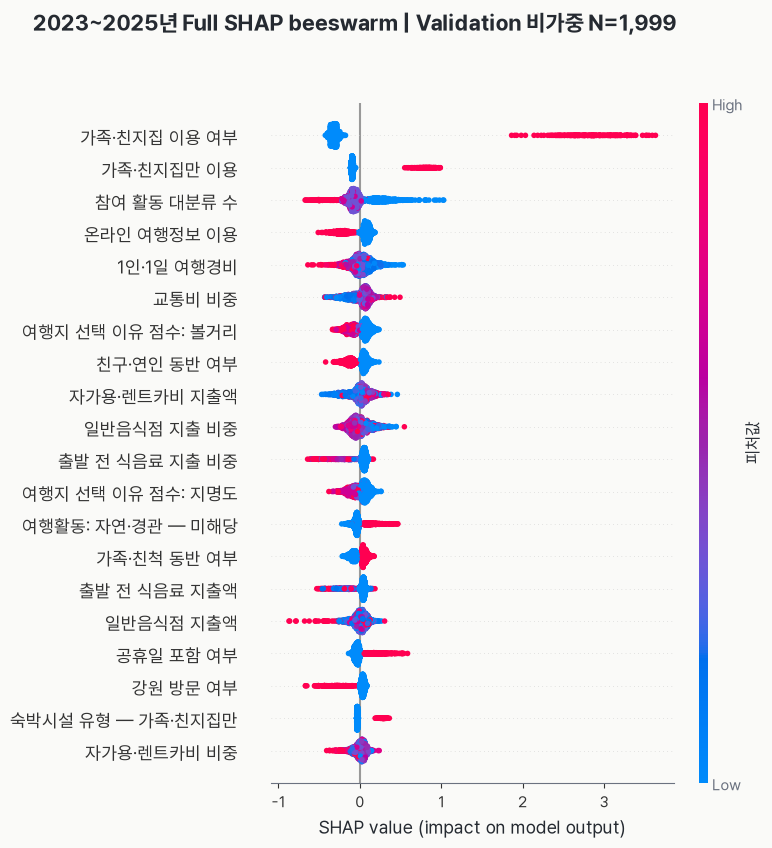

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\full_shap_beeswarm.png


In [14]:
for tier, result in shap_results.items():
    top_original = (
        result["original_summary"]
        .head(20)
        .sort_values("mean_abs_shap")
        .copy()
    )
    top_original["display_feature"] = top_original[
        "original_feature"
    ].map(feature_display_name).map(wrap_feature_label)

    figure, axis = plt.subplots(figsize=(9.5, 7.5))
    axis.barh(
        top_original["display_feature"],
        top_original["mean_abs_shap"],
        color=(
            COLORS["primary"]
            if tier == "Base"
            else COLORS["secondary"]
        ),
    )
    axis.set_xlabel("mean |SHAP|")
    axis.set_title(
        f"2023~2025년 {tier} 상위 20개 피처 | "
        f"Validation 비가중 N={shap_sample_n:,}"
    )
    figure.tight_layout()
    save_figure(
        figure,
        f"{tier.lower()}_shap_original_feature_bar.png",
    )

    shap.summary_plot(
        result["values"],
        result["data"],
        feature_names=result["display_feature_names"],
        max_display=20,
        color=SHAP_CMAP,
        show=False,
    )
    figure = plt.gcf()
    figure.set_size_inches(10.5, 8.5)
    figure.suptitle(
        f"2023~2025년 {tier} SHAP beeswarm | "
        f"Validation 비가중 N={shap_sample_n:,}",
        y=1.02,
    )
    if len(figure.axes) > 1:
        figure.axes[-1].set_ylabel("피처값")
    figure.subplots_adjust(
        left=0.42,
        right=0.90,
        top=0.91,
        bottom=0.11,
    )
    save_figure(
        figure,
        f"{tier.lower()}_shap_beeswarm.png",
    )

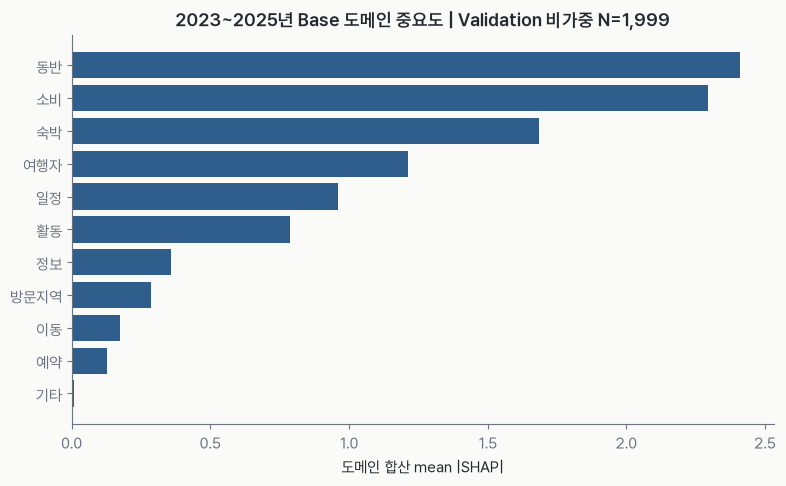

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\base_shap_domain_importance.png


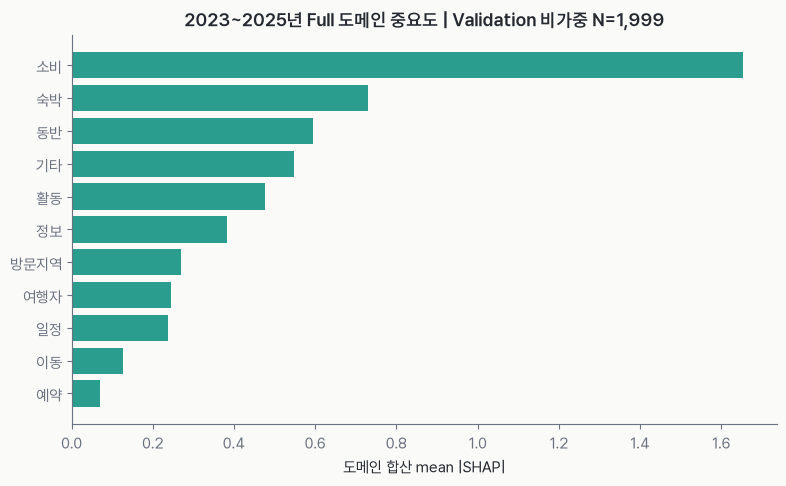

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\full_shap_domain_importance.png


In [15]:
for tier, result in shap_results.items():
    tier_domain = result["domain_summary"].sort_values(
        "mean_abs_shap"
    )
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.barh(
        tier_domain["domain"],
        tier_domain["mean_abs_shap"],
        color=(
            COLORS["primary"]
            if tier == "Base"
            else COLORS["secondary"]
        ),
    )
    axis.set_xlabel("도메인 합산 mean |SHAP|")
    axis.set_title(
        f"2023~2025년 {tier} 도메인 중요도 | "
        f"Validation 비가중 N={shap_sample_n:,}"
    )
    figure.tight_layout()
    save_figure(
        figure,
        f"{tier.lower()}_shap_domain_importance.png",
    )

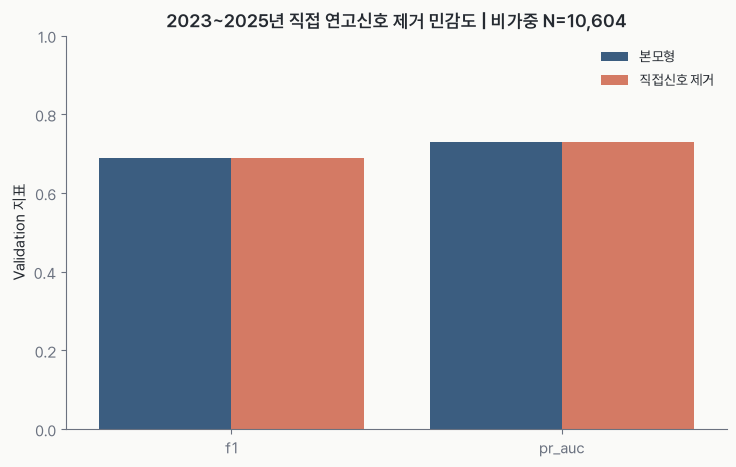

저장: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures\direct_signal_sensitivity_comparison.png


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/outputs/260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200/figures/direct_signal_sensitivity_comparison.png')

In [16]:
sensitivity_plot = sensitivity_comparison.melt(
    id_vars="configuration",
    value_vars=["f1", "pr_auc"],
    var_name="metric",
    value_name="value",
)
figure, axis = plt.subplots(figsize=(7.5, 4.8))
sns.barplot(
    data=sensitivity_plot,
    x="metric",
    y="value",
    hue="configuration",
    palette=[
        COLORS["primary"],
        COLORS["accent"],
    ],
    ax=axis,
)
axis.set_ylim(0, 1)
axis.set_xlabel("")
axis.set_ylabel("Validation 지표")
axis.set_title(
    "2023~2025년 직접 연고신호 제거 민감도 | "
    f"비가중 N={validation_n:,}"
)
axis.legend(frameon=False)
figure.tight_layout()
save_figure(
    figure,
    "direct_signal_sensitivity_comparison.png",
)

## 6. 완료 검증, 핵심 결과와 한계

- 원본 10개에 Base 도메인 중요도를 더한 11개 PNG가 새 출력 폴더에
  생성되어야 한다.
- 모든 그래프는 비가중 결과이며 모집단 효과 추정이 아니다.
- SHAP은 모델 안의 연관성과 방향을 요약하며 인과효과가 아니다.
- 민감도 비교는 Validation 진단이며 Test 성능 비교가 아니다.
- 이 노트북은 저장 결과를 재시각화할 뿐 모델을 재학습하지 않는다.

In [17]:
expected_filenames = {
    "sample_flow_and_year_case_composition.png",
    "validation_leaderboard_f1.png",
    "paired_bootstrap_f1_difference.png",
    "final_test_confusion_matrix_and_pr_curve.png",
    "base_shap_original_feature_bar.png",
    "base_shap_beeswarm.png",
    "base_shap_domain_importance.png",
    "full_shap_original_feature_bar.png",
    "full_shap_beeswarm.png",
    "full_shap_domain_importance.png",
    "direct_signal_sensitivity_comparison.png",
}
generated_filenames = {
    path.name for path in generated_figure_paths
}
assert generated_filenames == expected_filenames
assert all(
    path.is_file() and path.stat().st_size > 0
    for path in generated_figure_paths
)

print(f"그래프 {len(generated_figure_paths)}개 생성 완료")
print(f"결과 경로: {FIGURES_DIR}")

그래프 11개 생성 완료
결과 경로: C:\Users\ilove\OneDrive\Desktop\tourism_poster\outputs\260726_CASE1_CASE2_분류모형_그래프재생성_260726_2200\figures


In [18]:
from src.notebook_sync import sync_script_from_notebook


sync_script_from_notebook(
    "notebooks/03_Classification/"
    "260726_CASE1_CASE2_분류모형_그래프재생성.ipynb"
)

생성 스크립트를 노트북 기준으로 만들었습니다: C:\Users\ilove\OneDrive\Desktop\tourism_poster\script\260726_CASE1_CASE2_분류모형_그래프재생성.py


WindowsPath('C:/Users/ilove/OneDrive/Desktop/tourism_poster/script/260726_CASE1_CASE2_분류모형_그래프재생성.py')